## Scenario
This dataset show the student-related academic, lifestyle, and socio-enconmic factores that include exam perdormance. It include study hours, student attendence, sleep hours, motivation, tutoring sessions, parental involvement, school type and other environmental features. The main target varibale is Exam_Score which represents the student final exam score.


## Objective
This notebook is to Explore the Student Academic dataset and discover relationships and state some assumption and try to prove them, and note my discoveries

## Approach
Apply EDA to explore the data,  gather assumptions, and verify my assumption using statistical tests 

## **Code Setup**

In [12]:
# Standard libraries
from pathlib import Path

# Installed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

# Paths
DATA_PATH = Path('../data/raw/')
OUTPUT_PATH = Path('../output/')

#Stats
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

ALPHA=0.05

## **Data Loading And validation**


In [2]:
df = pd.read_csv(str(DATA_PATH) + '/StudentPerformanceFactors.csv')
print("Data Loaded\n")

print(f'Shape: {df.shape}\n')

print(f'Columns:\n {df.info()}\n')

df.head(5)


Data Loaded

Shape: (6607, 20)

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null 

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


# **EDA**
Here we will create assumptions and check those assumptions with **visualizations** and **Hypothesis Testing**

## Exploring and Check distribution of the data:

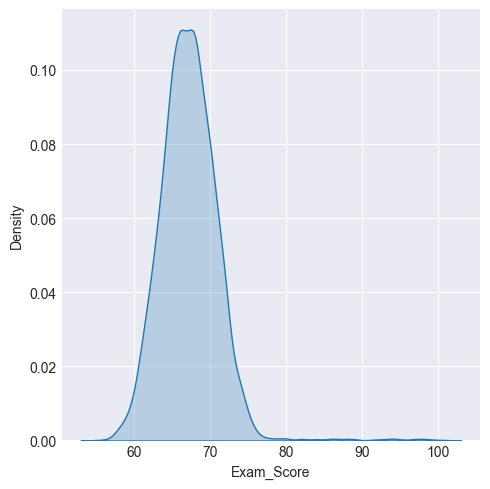

In [3]:
sns.displot(data=df,x='Exam_Score',kind='kde',fill='True')


In [19]:
df.isna().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

---


## Q1: More studied hours lead to better exam scores? 

Here i am going to use `sns.regplot` which is just a scatter plot with a regression line to better see the relationship

<Axes: xlabel='Hours_Studied', ylabel='Exam_Score'>

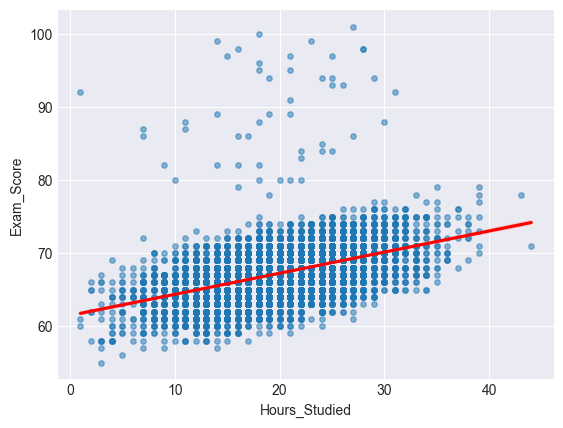

In [4]:
sns.regplot(data=df,x='Hours_Studied',y='Exam_Score',scatter_kws={'s': 15, 'alpha': 0.5},line_kws={'color': 'red'})

As we can see here from the viz Students with higher studying hours --> higher exam socre on average 

but we need to do Hypothesis testing to prove that there is a relation 

we will use pearson correlation to do it 

`H0` There is no relationship between Hours Studied and Exam scores

`H1` There is a relationship between Hours Studied and Exam Scores

In [5]:
r,p = stats.pearsonr(df['Hours_Studied'],y=df['Exam_Score'])

print(f'r={r}\nP-value: {p:.10f}')
if p < ALPHA:
    print(f'We Reject H0: There is relationship between Hours Studied and Exam scores')
else:
    print("We do not reject H0: There is no relationship between Hours Studied and Exam scores")
    


r=0.4454549540752818
P-value: 0.0000000000
We Reject H0: There is relationship between Hours Studied and Exam scores


**Insight**: Based on the data There is a moderate possitive relationship `r=0.44` between `Hours_Studied` and `exam_scores` 

---


## Q2: Do people with less parental involvment tend to have less atendance?

<Axes: xlabel='Parental_Involvement', ylabel='Attendance'>

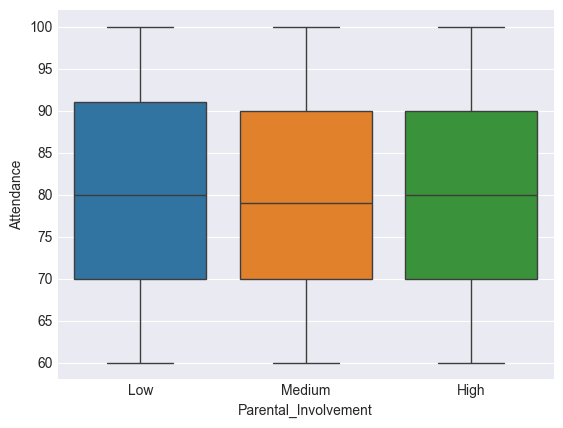

In [7]:
df['Parental_Involvement'].value_counts()

sns.boxplot(data=df,x='Parental_Involvement',y='Attendance',hue='Parental_Involvement')

From what i interpret from the viz there is no relationship between `Parental_Involvement` and `Attendance`

but we have to statistically check it using Hypothesis testing 

`H0` There is no relationship between Parental Involvement and attendance

`H1` There a relationship between Involvement and attendance

In [18]:
tukey = pairwise_tukeyhsd(endog=df['Attendance'],
                          groups=df['Parental_Involvement'],
                          alpha=ALPHA)

print(tukey)
print("significant! we reject H0" if (tukey.reject.any()) else "not enough evidence, We fail to reject H0")


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  High    Low    0.357 0.6612 -0.6085 1.3226  False
  High Medium  -0.0843 0.9648 -0.8603 0.6916  False
   Low Medium  -0.4414 0.4639 -1.3167 0.4339  False
---------------------------------------------------
not enough evidence, We fail to reject H0


**Insight**: There is no significant relationship between `Parental_Involvement` and `Attendance`

---